1. 원본 파일 'Oworld_temp.csv' 불러오기...
2. 공사 기간 데이터 제외 처리 ('2026-04-08' ~ '2026-06-03')...
-> 공사 기간 데이터 0행 제외 완료
3. 공휴일, 샌드위치 데이 및 이상치 데이터 반영...
4. 특성 융합 수행 (휴일(1) vs 평일(0))...
-> 'holiday_type' 생성 완료 (평일: 0, 휴일: 1)
5. 오버피팅 방지를 위한 불필요 피처 정리...
✨ 전처리 완료! 최종 파일이 'Oworld_final_processed_cleaned.csv'로 저장되었습니다.

6. 발표용 시각화 생성 중...


C:\Users\skdpa\AppData\Local\Temp\ipykernel_21584\315061589.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='holiday_label', palette='Set2', ax=axes[0])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_21584\315061589.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_visitors, x='holiday_label', y=visitor_col, palette='Pastel1', ax=axes[1])


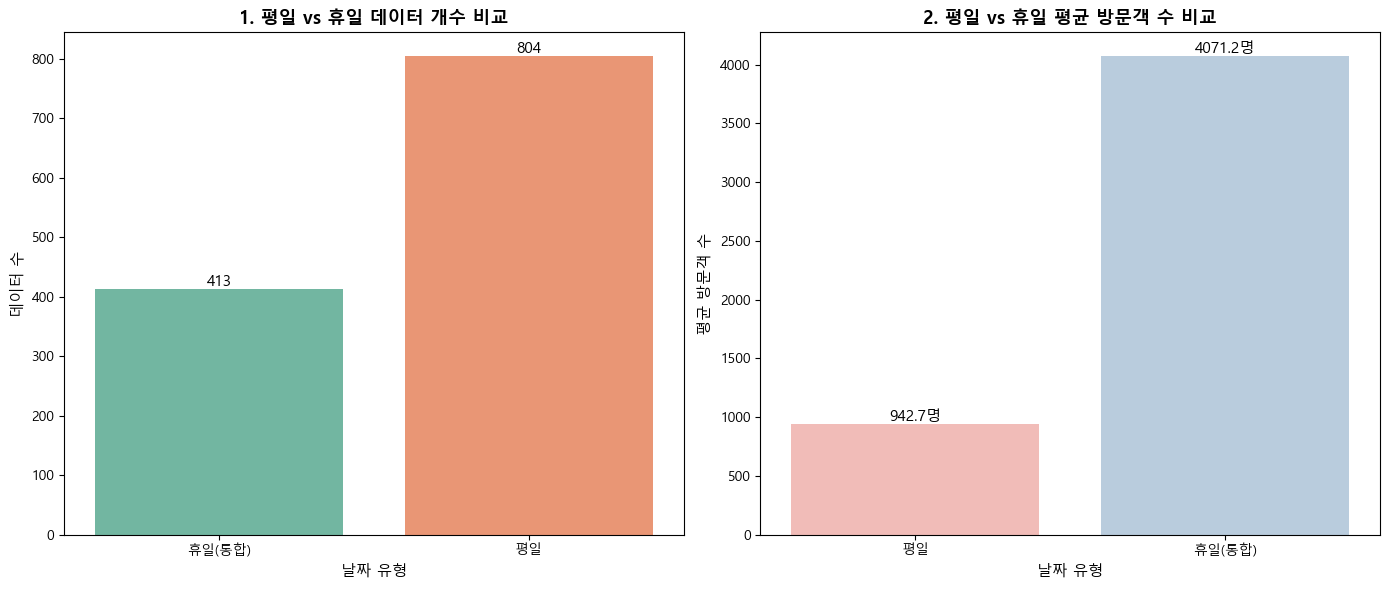

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 로드
df = pd.read_csv('Oworld_temp.csv')

# 2. 특성 융합 (휴일 통합 피처 생성)
# 주말, 공휴일, 샌드위치 데이 중 하나라도 1이면 휴일(1)로 분류
df['holiday_type'] = ((df['weekend'] == 1) | (df['holiday'] == 1) | (df['sandwich'] == 1)).astype(int)
df['holiday_label'] = df['holiday_type'].map({0: '평일', 1: '휴일(통합)'})

# 3. 4개의 핵심 분석 그래프 생성
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# [그래프 1] 평일 vs 휴일(통합) 평균 방문객 수
sns.barplot(data=df, x='holiday_label', y='visitors', palette='Pastel1', ax=axes[0])
axes[0].set_title('1. 평일 vs 휴일(통합) 평균 방문객')

# [그래프 2] 월별 평균 방문객 수 (원본 데이터의 월 원핫인코딩 활용)
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_visitors = []
for m in months:
    val = df[df[m] == 1]['visitors'].mean()
    monthly_visitors.append({'month': m, 'visitors': val})
monthly_df = pd.DataFrame(monthly_visitors)
sns.barplot(data=monthly_df, x='month', y='visitors', palette='viridis', ax=axes[1])
axes[1].set_title('2. 월별 평균 방문객')

# [그래프 3] 기온 vs 방문객 수 (상관관계 산점도)
sns.scatterplot(data=df, x='temperature', y='visitors', alpha=0.5, ax=axes[2])
axes[2].set_title('3. 기온 vs 방문객 수')

# [그래프 4] 날씨(강수 여부) vs 방문객
df['is_rain'] = (df['rain'] > 0).map({True: '비 옴', False: '맑음'})
sns.barplot(data=df, x='is_rain', y='visitors', palette='coolwarm', ax=axes[3])
axes[3].set_title('4. 강수 여부 vs 방문객')

plt.tight_layout()
plt.show()

# 4. 모델 학습용 데이터 저장
df.drop(columns=['is_rain'], inplace=True) # 시각화용 임시 컬럼 삭제
df.to_csv('Oworld_final_for_model.csv', index=False, encoding='utf-8-sig')
print("✨ 전처리 및 시각화 완료! 'Oworld_final_for_model.csv'로 저장되었습니다.")